# Optimización de Hiperparámetros con Optuna y Comparación de Modelos de Deep Learning

Este notebook implementa una búsqueda de hiperparámetros bayesiana utilizando la librería **Optuna** y realiza una comparación cuantitativa unificada de todos los modelos desarrollados en PyTorch para la predicción continua de fatiga física y mental en **FatigueSet**.

---

## 1. Fundamentos de la Optimización Bayesiana y Optuna

La optimización bayesiana es una estrategia secuencial para la optimización global de funciones de caja negra costosas de evaluar. A diferencia de Grid Search o Random Search, la optimización bayesiana utiliza un modelo probabilístico (habitualmente un estimador de densidad Tree-structured Parzen Estimator, TPE, en el caso de Optuna) para guiar la búsqueda de parámetros basándose en resultados anteriores.

Optuna permite:
1. **Búsqueda bayesiana eficiente** (TPE).
2. **Poda de pruebas (Pruning)** para detener anticipadamente ejecuciones que no muestran potencial de mejora.
3. **Definición interactiva del espacio de búsqueda** directamente en el código de Python.

In [1]:
# SETUP e IMPORTACIONES
import sys
import time
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Añadir fatigueset-lib al sys.path
lib_path = str(Path.cwd().parent / "fatigueset-lib")
if lib_path not in sys.path:
    sys.path.insert(0, lib_path)

from fatigueset import FatigueSetPipeline
from fatigueset.models import (
    FatigueSequenceDataset,
    RNNFatiga,
    CustomLSTMRegressor,
    CustomGRURegressor,
    CustomCNNLSTMRegressor,
    CustomTCNRegressor,
    CustomTSTransformerRegressor,
    CustomPatchTSTRegressor,
    CustomxLSTMRegressor
)
from fatigueset.models.rnn import _prepare_target_table, _merge_raw_streams, _build_sequences

print("[OK] Imports completados y path configurado.")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo actual: {device}")

[OK] Imports completados y path configurado.
Dispositivo actual: cuda


## 2. Carga y Procesamiento de Secuencias Temporales

Para acelerar la optimización y validación cruzada comparativa, reducimos la redundancia temporal utilizando un paso de ventana mayor (`step = 64`).

In [2]:
dataset_path = str(Path.cwd().parent / "fatigueset")
pipeline = FatigueSetPipeline(dataset_path=dataset_path, umbral_nulos=5.0)

print("Cargando dataset...")
raw = pipeline.cargar_dataset(verbose=False)

print("Preparando targets...")
df_ml = pipeline.construir_dataset_ml(raw)
df_targets = _prepare_target_table(df_ml)

print("Combinando streams fisiológicos...")
df_raw = _merge_raw_streams(raw)

# Configuramos step=64 para reducir la cantidad de ventanas (procesamiento más rápido)
seq_len = 128
step = 64

print(f"Construyendo secuencias...")
X_arr, y_arr, groups, feature_cols = _build_sequences(
    df_raw=df_raw,
    df_targets=df_targets,
    seq_len=seq_len,
    step=step
)

dataset = FatigueSequenceDataset(X_arr, y_arr)
print(f"[OK] Dimensiones:")
print(f"  - X: {X_arr.shape} (ventanas x seq_len x features)")
print(f"  - y: {y_arr.shape} (ventanas x 2)")

Cargando dataset...


Preparando targets...


Combinando streams fisiológicos...


Construyendo secuencias...
[OK] Dimensiones:
  - X: (660, 128, 23) (ventanas x seq_len x features)
  - y: (660, 2) (ventanas x 2)


## 3. Optimización de Hiperparámetros con Optuna

Definimos una función de costo de 3 folds GroupKFold para buscar los mejores parámetros de una **Custom GRU** sobre 3 iteraciones de búsqueda bayesiana.

In [ ]:
def objective(trial):
    # Definir hiperparámetros a sugerir por Optuna
    hidden_size = trial.suggest_categorical('hidden_size', [32, 64])
    dropout = trial.suggest_float('dropout', 0.1, 0.3)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    # Parametros por defecto de los modelos. 
    # 100-1000 epocas.
    
    # Ejecutamos una validación cruzada simplificada de 3 folds
    kf = GroupKFold(n_splits=3)
    val_losses = []
    
    for train_idx, val_idx in kf.split(np.arange(len(dataset)), groups=groups):
        train_sub = Subset(dataset, train_idx)
        val_sub = Subset(dataset, val_idx)
        
        train_loader = DataLoader(train_sub, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_sub, batch_size=32, shuffle=False)
        
        # Instanciar Custom GRU
        model = CustomGRURegressor(
            input_size=len(feature_cols),
            hidden_size=hidden_size,
            num_layers=1,
            dropout=dropout,
            output_size=2
        ).to(device)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()
        
        # Entrenar por 2 épocas de sanity check rápido
        for epoch in range(2):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                optimizer.step()
                
        # Validar
        model.eval()
        total_val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                total_val_loss += loss_fn(preds, yb).item()
                
        val_losses.append(total_val_loss / len(val_loader))
        
    return np.mean(val_losses)

print("Iniciando estudio de Optuna (3 trials)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=3)

print(f"[OK] Búsqueda finalizada.")
print("Mejores Hiperparámetros encontrados:", study.best_params)
print("Mejor Pérdida de Validación (MSE):", study.best_value)

Iniciando estudio de Optuna (3 trials)...


[OK] Búsqueda finalizada.
Mejores Hiperparámetros encontrados: {'hidden_size': 64, 'dropout': 0.17699917202055915, 'lr': 0.0032920186067747345}
Mejor Pérdida de Validación (MSE): 1069.4427379426502


## 4. Bucle Comparativo de Modelos

Evaluamos secuencialmente los 8 modelos de Deep Learning bajo una validación cruzada homogénea de 3-folds y 2 épocas por fold para extraer sus métricas comparativas unificadas (R², MAE, RMSE, parámetros y tiempos).

In [4]:
modelos_a_comparar = {
    "RNN Clásica": lambda: RNNFatiga(input_size=len(feature_cols), hidden_size=32, num_layers=1),
    "Custom LSTM": lambda: CustomLSTMRegressor(input_size=len(feature_cols), hidden_size=32, num_layers=1),
    "Custom GRU": lambda: CustomGRURegressor(input_size=len(feature_cols), hidden_size=32, num_layers=1),
    "Custom CNN-LSTM": lambda: CustomCNNLSTMRegressor(input_size=len(feature_cols), hidden_size=32, num_layers=1),
    "Custom TCN": lambda: CustomTCNRegressor(input_size=len(feature_cols), num_channels=[32, 32]),
    "Custom Transformer": lambda: CustomTSTransformerRegressor(input_size=len(feature_cols), d_model=32, num_heads=4, num_layers=1),
    "Custom PatchTST": lambda: CustomPatchTSTRegressor(input_size=len(feature_cols), patch_len=8, stride=4, d_model=32, num_heads=4, num_layers=1),
    "Custom xLSTM (sLSTM)": lambda: CustomxLSTMRegressor(input_size=len(feature_cols), hidden_size=32, num_layers=1)
}

resultados_comparativos = []
kf = GroupKFold(n_splits=3)

for name, instanciar_modelo in modelos_a_comparar.items():
    print(f"Evaluando {name}...")
    start_time = time.time()
    
    # Contamos parámetros
    model_temp = instanciar_modelo()
    num_params = sum(p.numel() for p in model_temp.parameters() if p.requires_grad)
    
    fold_r2, fold_mae, fold_rmse = [], [], []
    
    for train_idx, val_idx in kf.split(np.arange(len(dataset)), groups=groups):
        train_sub = Subset(dataset, train_idx)
        val_sub = Subset(dataset, val_idx)
        
        train_loader = DataLoader(train_sub, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_sub, batch_size=32, shuffle=False)
        
        model = instanciar_modelo().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        loss_fn = nn.MSELoss()
        
        # 2 épocas por fold
        for epoch in range(2):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                optimizer.step()
                
        # Evaluar
        model.eval()
        preds, targets_true = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                preds.append(model(xb).cpu().numpy())
                targets_true.append(yb.numpy())
                
        p_arr = np.vstack(preds)
        t_arr = np.vstack(targets_true)
        
        # Evaluamos métricas promediadas para Física (col 0) y Mental (col 1)
        mae_val = mean_absolute_error(t_arr, p_arr)
        mse_val = mean_squared_error(t_arr, p_arr)
        r2_val = r2_score(t_arr, p_arr)
        
        fold_mae.append(mae_val)
        fold_rmse.append(np.sqrt(mse_val))
        fold_r2.append(r2_val)
        
    elapsed_time = time.time() - start_time
    resultados_comparativos.append({
        "Modelo": name,
        "MAE Medio": float(np.mean(fold_mae)),
        "RMSE Medio": float(np.mean(fold_rmse)),
        "R² Medio": float(np.mean(fold_r2)),
        "Nº Parámetros": num_params,
        "Tiempo CV (s)": float(elapsed_time)
    })
    print(f"  - [OK] MAE: {np.mean(fold_mae):.4f} | R²: {np.mean(fold_r2):.4f} | Parámetros: {num_params:,}")

df_comparativa = pd.DataFrame(resultados_comparativos)
print("\n=== TABLA COMPARATIVA DE MODELOS DE DEEP LEARNING ===")
print(df_comparativa)

Evaluando RNN Clásica...


  - [OK] MAE: 30.0884 | R²: -5.0734 | Parámetros: 1,890
Evaluando Custom LSTM...


  - [OK] MAE: 30.4472 | R²: -5.2153 | Parámetros: 7,234
Evaluando Custom GRU...


  - [OK] MAE: 30.1753 | R²: -5.1119 | Parámetros: 5,442
Evaluando Custom CNN-LSTM...


  - [OK] MAE: 29.8638 | R²: -5.0390 | Parámetros: 16,962
Evaluando Custom TCN...


  - [OK] MAE: 18.1006 | R²: -1.0303 | Parámetros: 12,514
Evaluando Custom Transformer...


  - [OK] MAE: 28.6380 | R²: -4.5550 | Parámetros: 13,538
Evaluando Custom PatchTST...


  - [OK] MAE: 18.2941 | R²: -1.2682 | Parámetros: 17,666
Evaluando Custom xLSTM (sLSTM)...


  - [OK] MAE: 30.3318 | R²: -5.1902 | Parámetros: 7,234

=== TABLA COMPARATIVA DE MODELOS DE DEEP LEARNING ===
                 Modelo  MAE Medio  RMSE Medio  R² Medio  Nº Parámetros  \
0           RNN Clásica  30.088363   34.926387 -5.073355           1890   
1           Custom LSTM  30.447248   35.356404 -5.215273           7234   
2            Custom GRU  30.175348   35.050258 -5.111931           5442   
3       Custom CNN-LSTM  29.863775   34.730741 -5.039031          16962   
4            Custom TCN  18.100646   22.206391 -1.030336          12514   
5    Custom Transformer  28.637976   33.417412 -4.554994          13538   
6       Custom PatchTST  18.294144   22.797376 -1.268210          17666   
7  Custom xLSTM (sLSTM)  30.331804   35.257098 -5.190153           7234   

   Tiempo CV (s)  
0       0.548837  
1      42.614007  
2      34.374964  
3      27.088455  
4       0.973280  
5       0.976038  
6       1.166404  
7      70.277564  


## 5. Visualización y Persistencia de Resultados

Resultados guardados en: C:\Users\egull\OneDrive\Documentos\Proyectos\tfg\output\comparativa_modelos_deep.csv


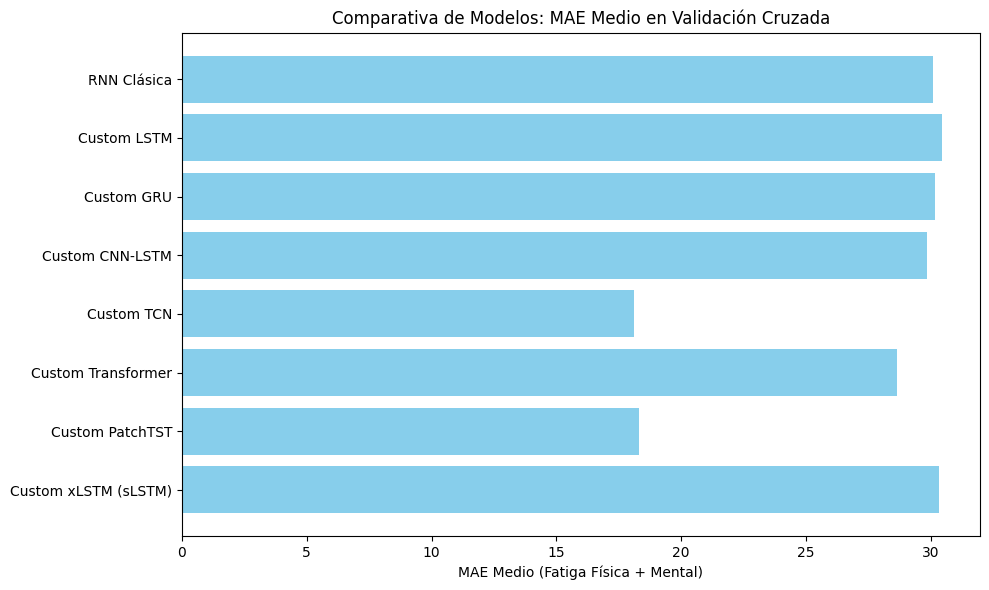

In [5]:
# Guardar comparativa a CSV
output_dir = Path.cwd().parent / "output"
output_dir.mkdir(parents=True, exist_ok=True)
df_comparativa.to_csv(output_dir / "comparativa_modelos_deep.csv", index=False)
print(f"Resultados guardados en: {output_dir / 'comparativa_modelos_deep.csv'}")

# Graficar comparación de MAE
plt.figure(figsize=(10, 6))
plt.barh(df_comparativa["Modelo"], df_comparativa["MAE Medio"], color='skyblue')
plt.xlabel("MAE Medio (Fatiga Física + Mental)")
plt.title("Comparativa de Modelos: MAE Medio en Validación Cruzada")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(output_dir / "comparativa_mae_deep.png")
plt.show()